<a href="https://colab.research.google.com/github/sabinetizen-hash/Anurag-kumar/blob/master/Anurag_2512042_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Job Salary Prediction Dataset

In [20]:
import pandas as pd
import numpy as np
#Load the dataset
df = pd.read_csv('/content/job_salary_prediction_dataset (1).csv')
# Display first 5 rows
print("First 5 rows of dataset:\n")
print(df.head())
#Basic dataset information
print("\n===================================")
print("Dataset Shape")
print("===================================")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
# Calculate missing values
print("\n===================================")
print("Missing Value Analysis")
print("===================================")
missing_values = df.isnull().sum()
missing_fraction = missing_values / len(df)
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Fraction Missing': missing_fraction
})
print(missing_summary[missing_summary['Missing Values'] > 0])
total_missing = df.isnull().sum().sum()
total_cells = np.prod(df.shape)

overall_missing_fraction = total_missing / total_cells

print("\nOverall Fraction of Missing Data:")
print(round(overall_missing_fraction, 4))
# Identify variable types
print("\n===================================")
print("Variable Type Identification")
print("===================================")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Detect text columns
text_cols = []

for col in categorical_cols:

    # Convert values to string and calculate average length
    avg_length = df[col].astype(str).apply(len).mean()

    if avg_length > 30:
        text_cols.append(col)
categorical_cols = [col for col in categorical_cols if col not in text_cols]
# Print summary
print("\nNumerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

print("\nText Variables:")
print(text_cols)
print("\n===================================")
print("Dataset Summary")
print("===================================")
# Dataset summary
print(df.info())
print("\nNumerical Summary:")
print(df.describe())
print("\nCategorical Summary:")
print(df.describe(include='object'))

First 5 rows of dataset:

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  

Dataset Shape
Rows: 250000
Columns: 10

Missing Value Analys

task1 : 2] Perform data preprocessing:

First 5 rows of dataset:

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  

Missing Values Before Handling
job_title           0
experie

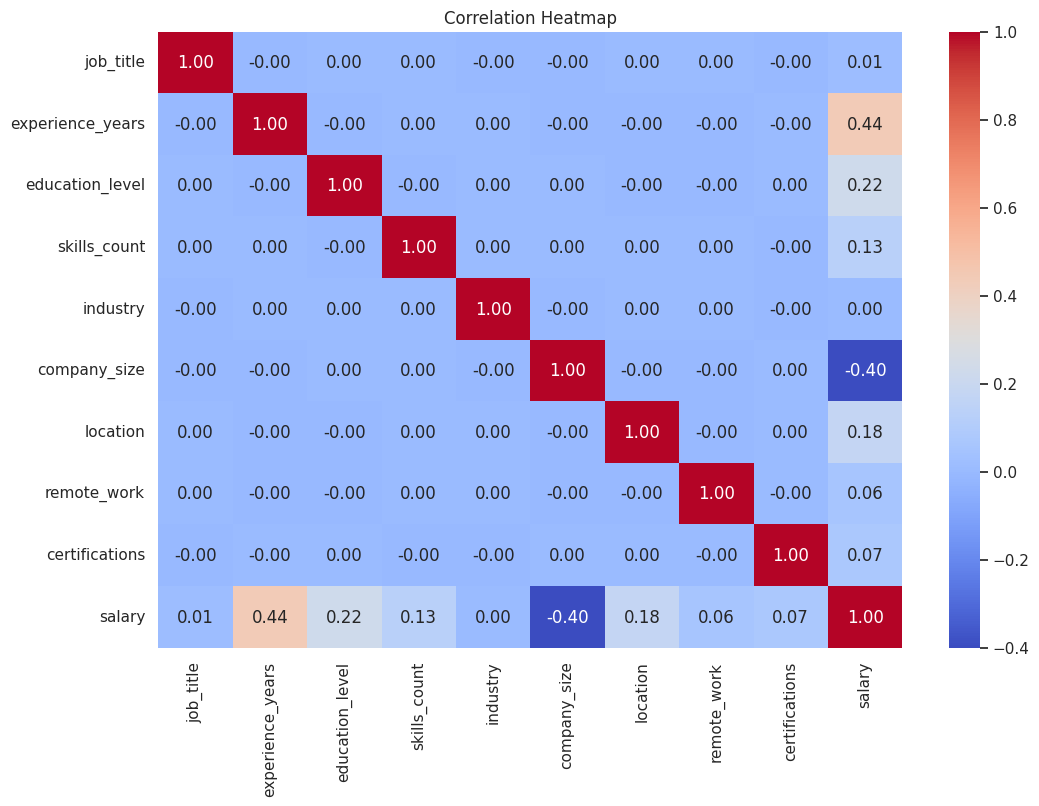

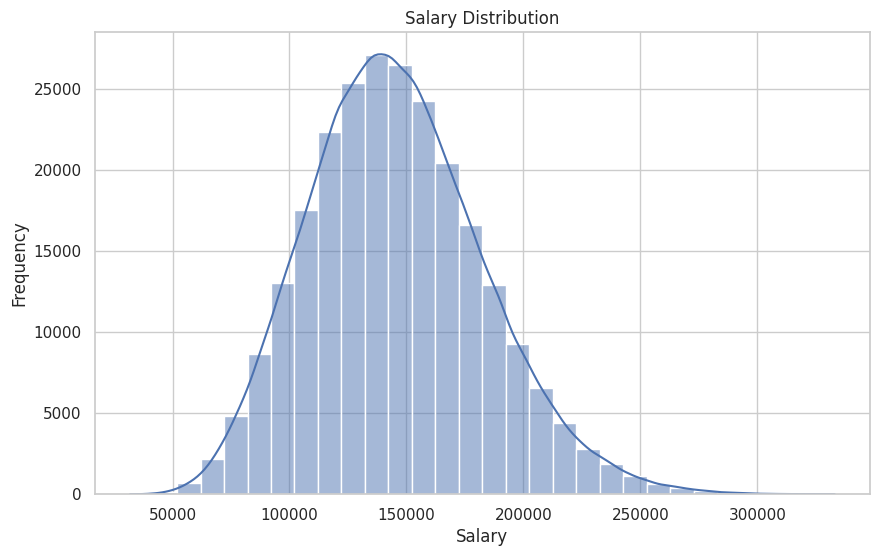

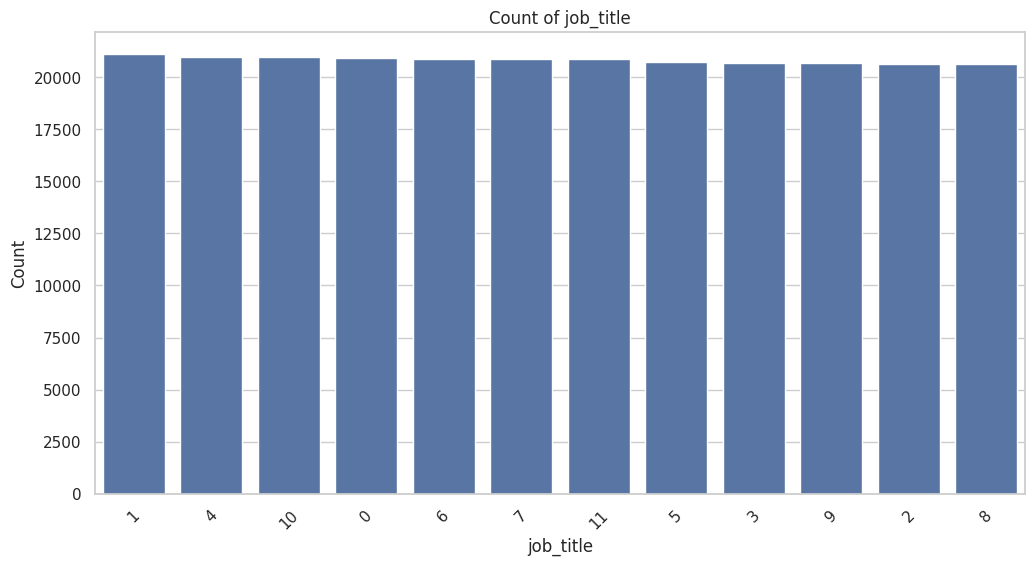


Final Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  int64
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  int64
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  int64
 5   company_size      250000 non-null  int64
 6   location          250000 non-null  int64
 7   remote_work       250000 non-null  int64
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(10)
memory usage: 19.1 MB
None


In [22]:
import pandas as pd
import numpy as np
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
# Load Dataset
df = pd.read_csv('/content/job_salary_prediction_dataset (1).csv')
print("First 5 rows of dataset:\n")
print(df.head())
# Check Missing Values
print("\n===================================")
print("Missing Values Before Handling")
print("===================================")
print(df.isnull().sum())
# Handle Missing Values
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
# Handle numerical missing values
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
# Handle numerical missing values
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
# Verify missing values after preprocessing
print("\n===================================")
print("Missing Values After Handling")
print("===================================")
print(df.isnull().sum())
# Encode Categorical Variables
print("\n===================================")
print("Encoding Categorical Variables")
print("===================================")
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print("Categorical variables encoded successfully!")
print("\nEncoded Dataset Sample:\n")
print(df.head())
# Exploratory Data Analysis (EDA)
sns.set(style="whitegrid")
plt.figure(figsize=(12,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()
salary_column = 'salary'

plt.figure(figsize=(10,6))

sns.histplot(df[salary_column],
             kde=True,
             bins=30)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()
categorical_feature = 'job_title'

plt.figure(figsize=(12,6))
sns.countplot(x=df[categorical_feature],
              order=df[categorical_feature].value_counts().index)

plt.title(f"Count of {categorical_feature}")
plt.xlabel(categorical_feature)
plt.ylabel("Count")

# Rotate labels for readability
plt.xticks(rotation=45)

plt.show()
print("\n===================================")
print("Final Dataset Information")
print("===================================")

print(df.info())

Build a regression model to predict diamond prices using ML algorithm(s).

Dataset Preview:

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  


/tmp/ipykernel_695/1104398038.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_695/1104398038.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us


Categorical variables encoded successfully!

Feature Shape: (250000, 9)
Target Shape: (250000,)

Training Data Shape: (200000, 9)
Testing Data Shape: (50000, 9)

Linear Regression Performance
MAE : 21740.62378138302
RMSE: 27497.625538838674
R2 Score: 0.4559758296725783

Random Forest Performance
MAE : 5183.920597850952
RMSE: 6557.204432414834
R2 Score: 0.96906392186884

Model Comparison
               Model           MAE          RMSE  R2 Score
0  Linear Regression  21740.623781  27497.625539  0.455976
1      Random Forest   5183.920598   6557.204432  0.969064


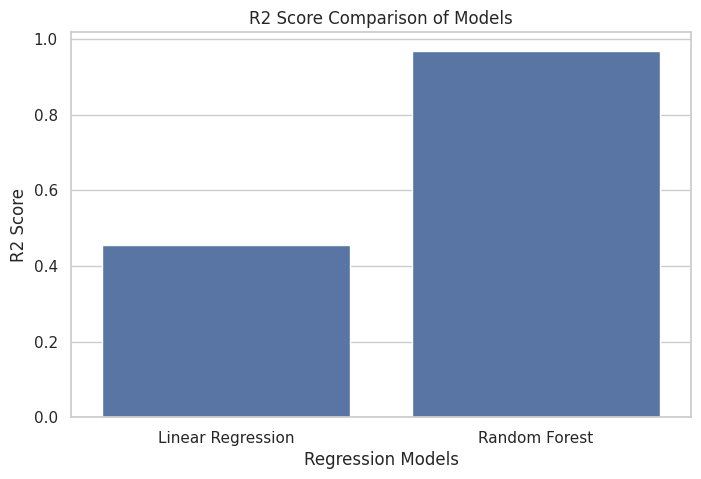

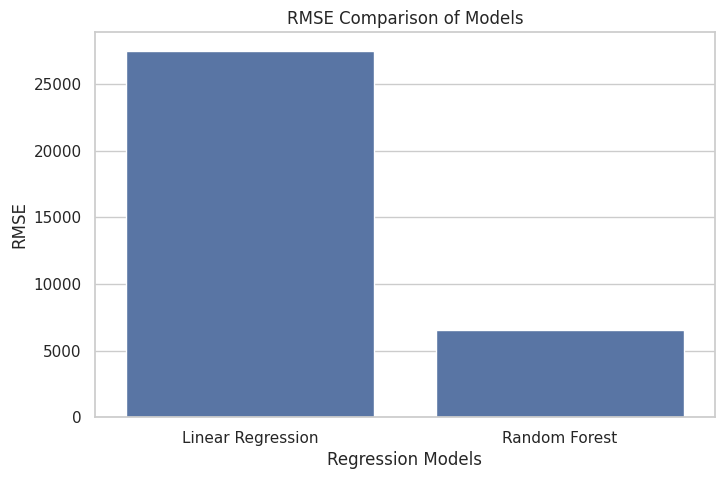

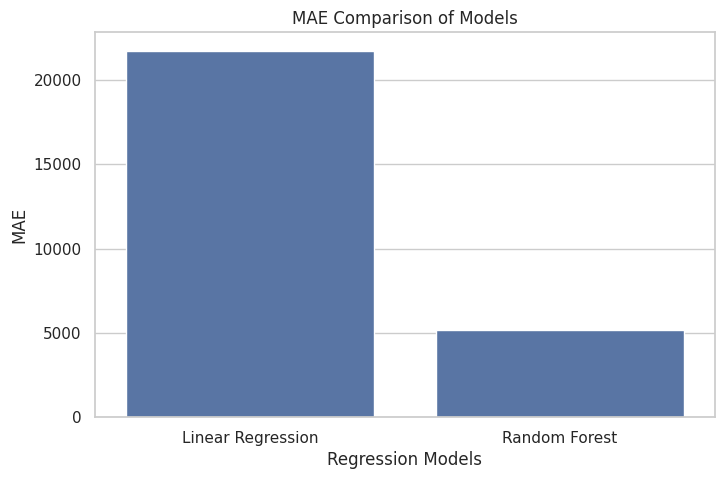


Conclusion
Random Forest performed better based on R2 Score.

Training Data Shape: (200000, 9)
Testing Data Shape: (50000, 9)

Linear Regression Performance
MAE : 21740.62378138302
RMSE: 27497.625538838674
R2 Score: 0.4559758296725783

Random Forest Performance
MAE : 5183.920597850952
RMSE: 6557.204432414834
R2 Score: 0.96906392186884

Model Comparison
               Model           MAE          RMSE  R2 Score
0  Linear Regression  21740.623781  27497.625539  0.455976
1      Random Forest   5183.920598   6557.204432  0.969064


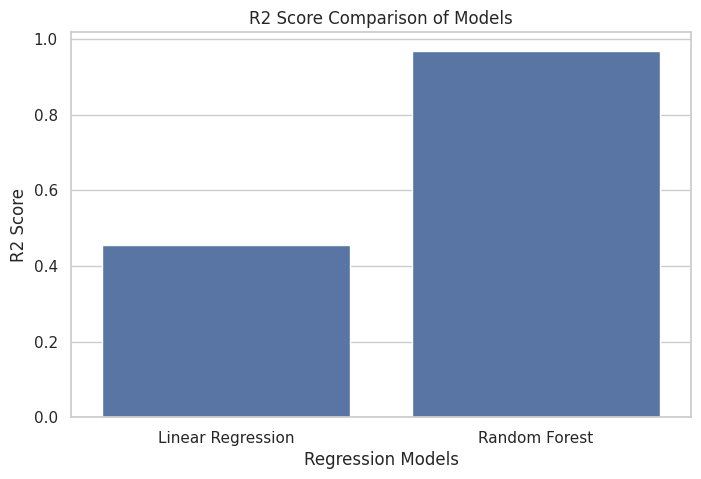

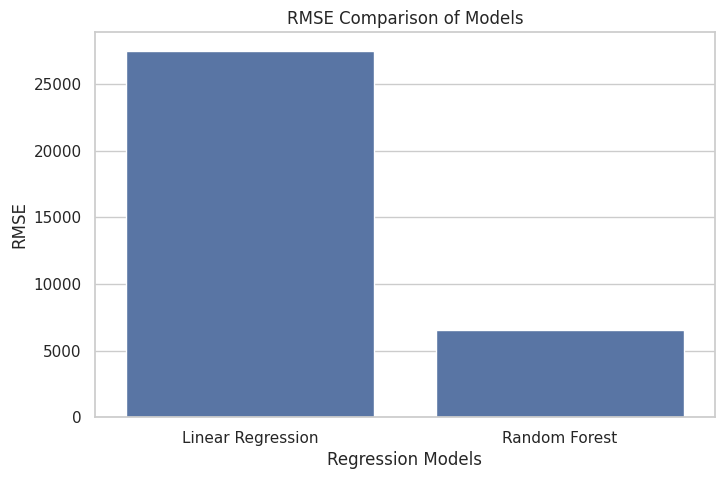

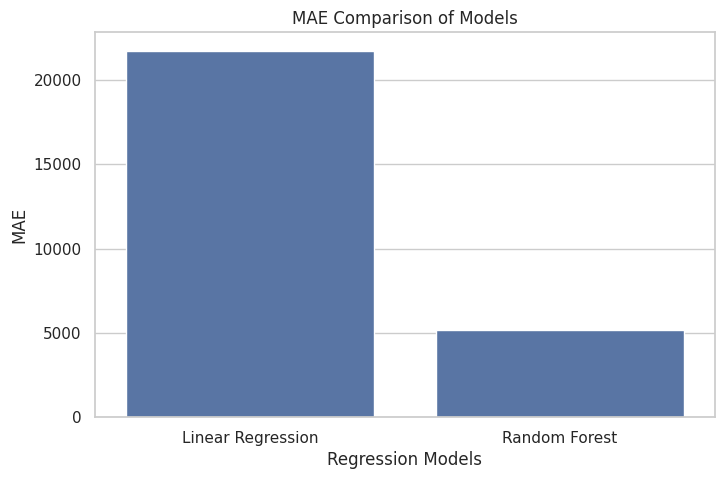


Conclusion
Random Forest performed better based on R2 Score.


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('/content/job_salary_prediction_dataset (1).csv')
print("Dataset Preview:\n")
print(df.head())
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

le = LabelEncoder()

# Apply encoding on all categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nCategorical variables encoded successfully!")
target_column = 'salary'

X = df.drop(target_column, axis=1)
y = df[target_column]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("\n===================================")
print("Linear Regression Performance")
print("===================================")

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("\n===================================")
print("Random Forest Performance")
print("===================================")

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print("\n===================================")
print("Model Comparison")
print("===================================")

print(comparison_df)
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=comparison_df
)

plt.title("R2 Score Comparison of Models")
plt.ylabel("R2 Score")
plt.xlabel("Regression Models")

plt.show()

# ----------------------------------------------------------
# Bar Chart for RMSE Comparison
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='RMSE',
    data=comparison_df
)

plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.xlabel("Regression Models")

plt.show()

# ----------------------------------------------------------
# Bar Chart for MAE Comparison
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='MAE',
    data=comparison_df
)

plt.title("MAE Comparison of Models")
plt.ylabel("MAE")
plt.xlabel("Regression Models")

plt.show()
print("\n===================================")
print("Conclusion")
print("===================================")

if rf_r2 > lr_r2:
    print("Random Forest performed better based on R2 Score.")
else:
    print("Linear Regression performed better based on R2 Score.")


print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("\n===================================")
print("Linear Regression Performance")
print("===================================")

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("\n===================================")
print("Random Forest Performance")
print("===================================")

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print("\n===================================")
print("Model Comparison")
print("===================================")

print(comparison_df)
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=comparison_df
)

plt.title("R2 Score Comparison of Models")
plt.ylabel("R2 Score")
plt.xlabel("Regression Models")

plt.show()
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='RMSE',
    data=comparison_df
)

plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.xlabel("Regression Models")

plt.show()
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='MAE',
    data=comparison_df
)

plt.title("MAE Comparison of Models")
plt.ylabel("MAE")
plt.xlabel("Regression Models")

plt.show()
print("\n===================================")
print("Conclusion")
print("===================================")

if rf_r2 > lr_r2:
    print("Random Forest performed better based on R2 Score.")
else:
    print("Linear Regression performed better based on R2 Score.")